# 1.1 Reddit — Exploratory Data Analysis

**Pipeline:**  
Bronze → language filter (English only) → text cleaning → buzz labels → **Silver** (`reddit_posts_clean.parquet` · `reddit_comments_clean.parquet`)

Downstream notebooks: network (1.2) · textual (1.3) · NLP (1.4) · sentiment (1.4)

<!-- toc -->
## Contents
- [1. Bronze — raw data structure](#1-bronze-raw-data-structure)
- [2. Text preprocessing → Buzz labels → Silver](#2-text-preprocessing-buzz-labels-silver)
- [3. Exploratory Analysis](#3-exploratory-analysis)
  - [Key counts per candidate](#key-counts-per-candidate)
  - [Posts by subreddit](#posts-by-subreddit)
  - [Daily post volume](#daily-post-volume)
  - [Score distribution (log scale)](#score-distribution-log-scale)
  - [Word count distribution](#word-count-distribution)


In [6]:
import sys, os
from pathlib import Path
sys.path.insert(0, os.path.join(os.path.abspath("."), "..", ".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from house_style import *
import nltk
nltk.download('stopwords',                    quiet=True)
nltk.download('punkt',                        quiet=True)
nltk.download('punkt_tab',                    quiet=True)
nltk.download('averaged_perceptron_tagger',   quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from Functions.text_preprocessing import apply_text_cleaning
from Functions.buzz_column import add_buzz_labels

apply_style()

BRONZE_DIR = Path("../../Data/1_Bronze/Reddit")
SILVER_DIR = Path("../../Data/2_Silver/Reddit")

POST_COLS    = ["id", "author", "created_utc", "subreddit", "title", "selftext",
                "score", "upvote_ratio", "num_comments", "permalink"]
COMMENT_COLS = ["id", "author", "created_utc", "subreddit", "body", "score", "permalink"]

posts    = pd.read_parquet(BRONZE_DIR / "reddit_posts_filtered.parquet",    columns=POST_COLS)
comments = pd.read_parquet(BRONZE_DIR / "reddit_comments_filtered.parquet", columns=COMMENT_COLS)

posts["created_utc"]    = pd.to_datetime(posts["created_utc"],    utc=True)
comments["created_utc"] = pd.to_datetime(comments["created_utc"], utc=True)

print(f"Posts    : {len(posts):,} rows x {posts.shape[1]} columns")
print(f"Comments : {len(comments):,} rows x {comments.shape[1]} columns")

Posts    : 111,003 rows x 10 columns
Comments : 1,400,420 rows x 7 columns


## 1. Bronze — raw data structure

In [7]:
posts.head(3)

,id,author,created_utc,subreddit,title,selftext,score,upvote_ratio,num_comments,permalink
0,1dvl0nn,ProfessionalSwim6159,2024-07-05 00:08:23+00:00,conservative,Economist editorial mocking Biden with image o...,,80,0.72,13,/r/Conservative/comments/1dvl0nn/economist_edi...
1,1dvlbuv,ngoni,2024-07-05 00:25:36+00:00,conservative,The Economist Blisters 'Befuddled Old Man' Bid...,,68,0.70,14,/r/Conservative/comments/1dvlbuv/the_economist...
2,1dvllmo,No_Patience_6801,2024-07-05 00:40:40+00:00,conservative,What’s going on with CNN?,I’ve been watching the past couple days and it...,495,0.82,368,/r/Conservative/comments/1dvllmo/whats_going_o...


In [8]:
comments.head(3)

,id,author,created_utc,subreddit,body,score,permalink
0,lbo95fd,Rabbits-and-Bears,2024-07-05 00:03:52+00:00,conservative,"So, Joe is the first woman president? Wow!",9,/r/Conservative/comments/1dvif61/im_proud_to_b...
1,lbo9kl7,Right_Archivist,2024-07-05 00:06:59+00:00,conservative,"If they can't turn his campaign around, they'r...",9,/r/Conservative/comments/1dve0sf/real_cover_of...
2,lbo9o44,whicky1978,2024-07-05 00:07:45+00:00,conservative,Exactly even if you have to walk across hot co...,5,/r/Conservative/comments/1dvawjn/current_ec_ma...


In [9]:
print("--- POSTS ---")
posts.info()
print()
print("--- COMMENTS ---")
comments.info()

--- POSTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111003 entries, 0 to 111002
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   id            111003 non-null  object             
 1   author        111003 non-null  object             
 2   created_utc   111003 non-null  datetime64[ms, UTC]
 3   subreddit     111003 non-null  object             
 4   title         111003 non-null  object             
 5   selftext      111003 non-null  object             
 6   score         111003 non-null  int64              
 7   upvote_ratio  111003 non-null  float64            
 8   num_comments  111003 non-null  int64              
 9   permalink     111003 non-null  object             
dtypes: datetime64[ms, UTC](1), float64(1), int64(2), object(6)
memory usage: 8.5+ MB

--- COMMENTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400420 entries, 0 to 1400419
Data columns (total

## 2. Text preprocessing → Buzz labels → Silver

Posts use `title + selftext` as the text field. Comments use `body`.  
Deleted/removed content (`[deleted]`, `[removed]`) is treated as empty.

In [10]:
# Posts: combine title + selftext into a single text column
def _combine_post_text(row):
    title    = str(row["title"])    if pd.notna(row["title"])    else ""
    selftext = str(row["selftext"]) if pd.notna(row["selftext"]) else ""
    selftext = "" if selftext in ("[deleted]", "[removed]") else selftext
    return (title + " " + selftext).strip()

posts["text"]    = posts.apply(_combine_post_text, axis=1)

# Comments: body is the text column
comments["text"] = comments["body"].replace({"[deleted]": "", "[removed]": ""})

# Apply cleaning + English filter
posts_clean    = apply_text_cleaning(posts,    text_col="text", filter_english=True)
comments_clean = apply_text_cleaning(comments, text_col="text", filter_english=True)

# Add buzz labels
posts_clean    = add_buzz_labels(posts_clean,    text_col="text_clean")
comments_clean = add_buzz_labels(comments_clean, text_col="text_clean")

# Save to Silver
SILVER_DIR.mkdir(parents=True, exist_ok=True)
posts_clean.to_parquet(   SILVER_DIR / "reddit_posts_clean.parquet",    index=False)
comments_clean.to_parquet(SILVER_DIR / "reddit_comments_clean.parquet", index=False)

print(f"Saved posts    : {len(posts_clean):,} rows x {posts_clean.shape[1]} cols")
print(f"Saved comments : {len(comments_clean):,} rows x {comments_clean.shape[1]} cols")

Detecting language for 111,003 rows (this may take a moment)...
✓ Language filter: kept 105,017 English rows (dropped 5,986 non-English, 5.4%)
✓ Cleaned 'text' → 'text_clean'
  Rows       : 105,017
  Avg words  : 11.1
  Empty texts: 2

                                          text_clean  word_count
0  economist editorial mocking biden image walker...          10
1  economist blisters befuddled old man biden bru...          11
2  going cnn watching past couple days largely an...          13
Detecting language for 1,400,420 rows (this may take a moment)...
✓ Language filter: kept 1,376,013 English rows (dropped 24,407 non-English, 1.7%)
✓ Cleaned 'text' → 'text_clean'
  Rows       : 1,376,013
  Avg words  : 24.1
  Empty texts: 302

                                          text_clean  word_count
0                      joe first woman president wow           5
1  turn campaign around going visit daughter ashl...           8
2  exactly even walk across hot coals shards glas...           9

## 3. Exploratory Analysis

All analyses below run on the Silver data: English only, cleaned, labelled.

In [11]:
posts_clean[["title", "text_clean", "word_count", "candidate", "subreddit"]].head(5)

,title,text_clean,word_count,candidate,subreddit
0,Economist editorial mocking Biden with image o...,economist editorial mocking biden image walker...,10,HarrisBuzz,conservative
1,The Economist Blisters 'Befuddled Old Man' Bid...,economist blisters befuddled old man biden bru...,11,HarrisBuzz,conservative
2,What’s going on with CNN?,going cnn watching past couple days largely an...,13,HarrisBuzz,conservative
3,"Disney heiress, wealthy Democratic donors say ...",disney heiress wealthy democratic donors say f...,11,HarrisBuzz,conservative
4,California delegate says Black women will 'blo...,california delegate says black women blow part...,13,HarrisBuzz,conservative


### Key counts per candidate

In [12]:
COLORS = {"TrumpBuzz": REPUBLICAN, "HarrisBuzz": DEMOCRAT, "ElectionBuzz": NEUTRAL}

summary = pd.DataFrame({
    "posts"           : posts_clean.groupby("candidate").size(),
    "unique_authors"  : posts_clean.groupby("candidate")["author"].nunique(),
    "avg_score"       : posts_clean.groupby("candidate")["score"].mean().round(1),
    "avg_comments"    : posts_clean.groupby("candidate")["num_comments"].mean().round(1),
    "avg_upvote_ratio": posts_clean.groupby("candidate")["upvote_ratio"].mean().round(3),
})
summary

,posts,unique_authors,avg_score,avg_comments,avg_upvote_ratio
candidate,,,,,
ElectionBuzz,25003,10911,483.4,61.6,0.837
HarrisBuzz,37055,12200,430.4,62.6,0.786
TrumpBuzz,42959,17147,597.2,57.5,0.858


### Posts by subreddit

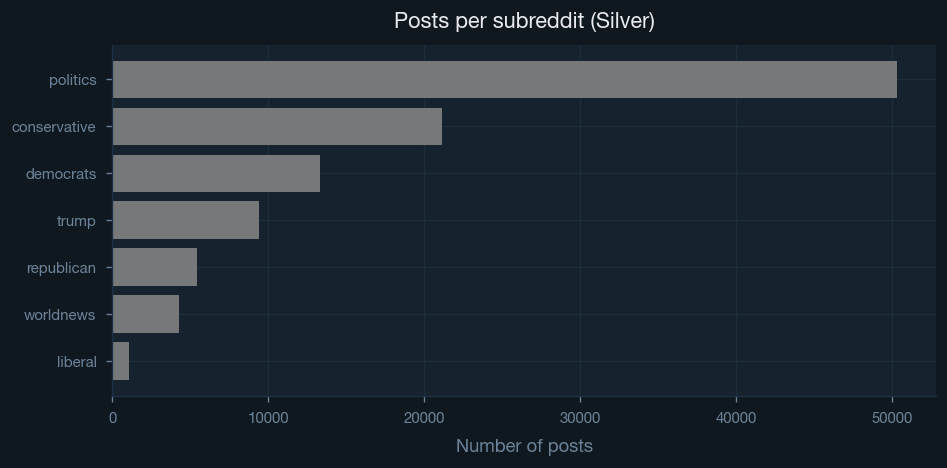

In [13]:
sub_counts = posts_clean["subreddit"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sub_counts.index[::-1], sub_counts.values[::-1], color=NEUTRAL)
ax.set_xlabel("Number of posts", color=TEXT_MUTED)
ax.set_title("Posts per subreddit (Silver)", color=TEXT_PRIMARY, pad=10)
plt.tight_layout()
plt.show()

### Daily post volume

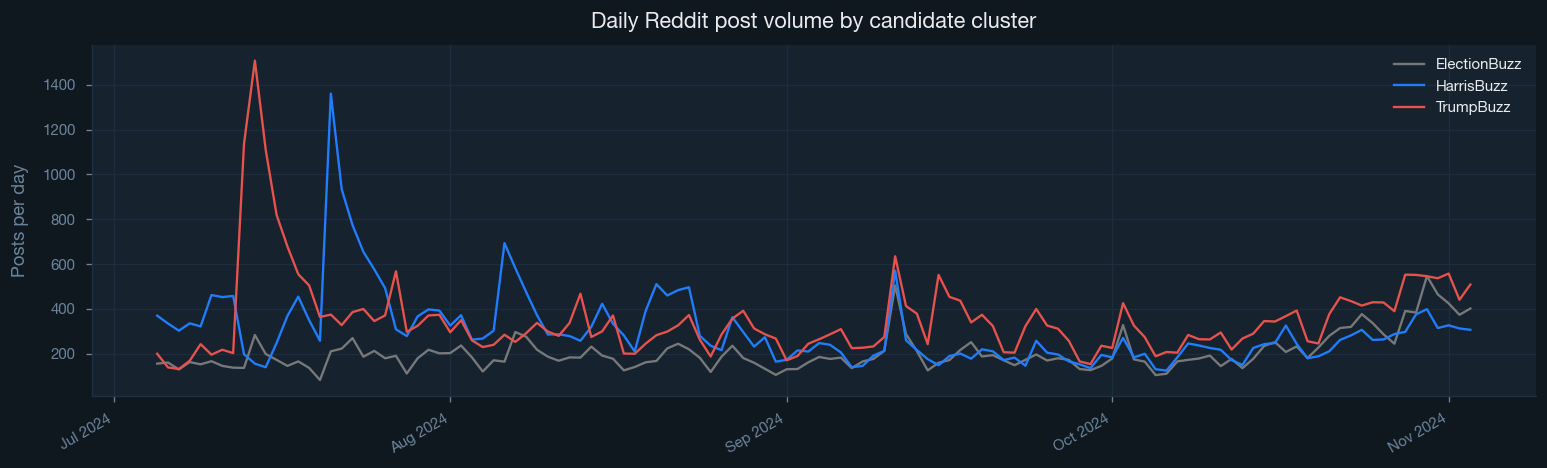

In [14]:
posts_clean["date"] = posts_clean["created_utc"].dt.normalize()

daily = posts_clean.groupby(["date", "candidate"]).size().reset_index(name="posts")

fig, ax = plt.subplots(figsize=(13, 4))
for cand, grp in daily.groupby("candidate"):
    ax.plot(grp["date"], grp["posts"], label=cand,
            color=COLORS.get(cand, NEUTRAL), linewidth=1.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel("Posts per day", color=TEXT_MUTED)
ax.set_title("Daily Reddit post volume by candidate cluster", color=TEXT_PRIMARY, pad=10)
ax.legend(frameon=False, labelcolor=TEXT_PRIMARY)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Score distribution (log scale)

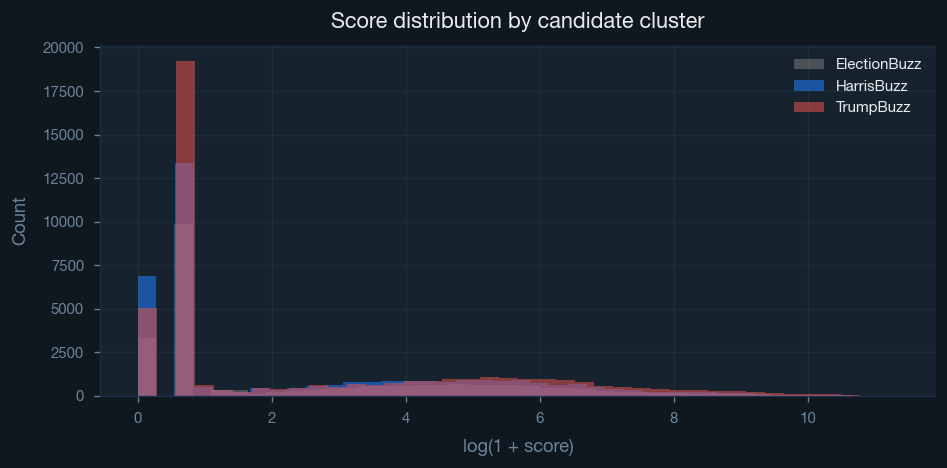

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
for cand, grp in posts_clean.groupby("candidate"):
    ax.hist(np.log1p(grp["score"].clip(lower=0)), bins=40, alpha=0.55,
            label=cand, color=COLORS.get(cand, NEUTRAL))
ax.set_xlabel("log(1 + score)", color=TEXT_MUTED)
ax.set_ylabel("Count", color=TEXT_MUTED)
ax.set_title("Score distribution by candidate cluster", color=TEXT_PRIMARY, pad=10)
ax.legend(frameon=False, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()

### Word count distribution

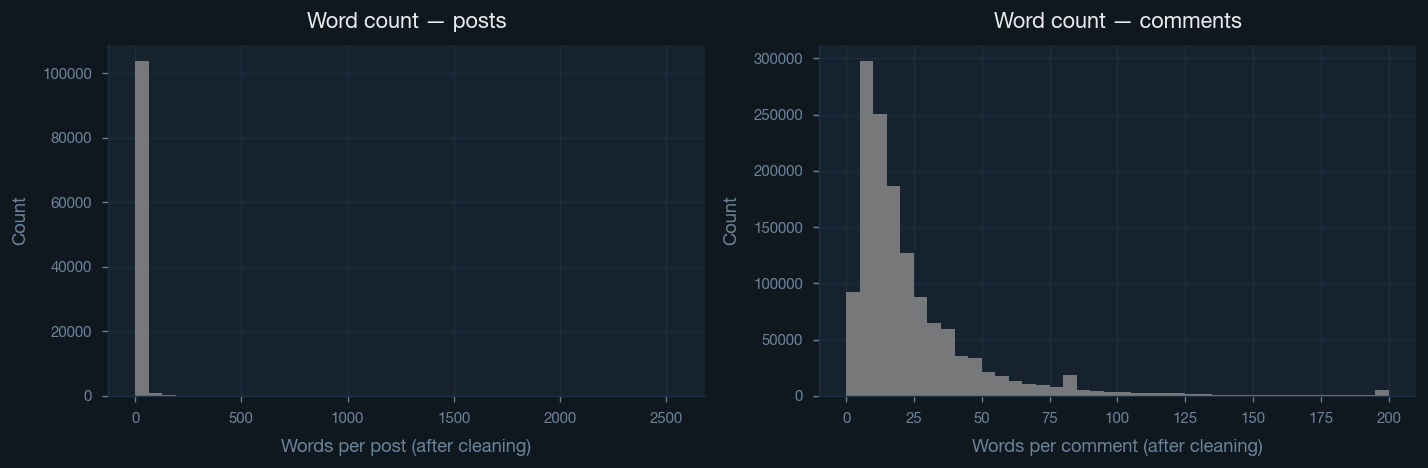

Empty posts    after cleaning : 2 (0.0%)
Empty comments after cleaning : 302 (0.0%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(posts_clean["word_count"], bins=40, color=NEUTRAL, edgecolor="none")
ax.set_xlabel("Words per post (after cleaning)", color=TEXT_MUTED)
ax.set_ylabel("Count", color=TEXT_MUTED)
ax.set_title("Word count — posts", color=TEXT_PRIMARY, pad=10)

ax = axes[1]
ax.hist(comments_clean["word_count"].clip(upper=200), bins=40, color=NEUTRAL, edgecolor="none")
ax.set_xlabel("Words per comment (after cleaning)", color=TEXT_MUTED)
ax.set_ylabel("Count", color=TEXT_MUTED)
ax.set_title("Word count — comments", color=TEXT_PRIMARY, pad=10)

plt.tight_layout()
plt.show()

empty_posts    = (posts_clean["word_count"]    == 0).sum()
empty_comments = (comments_clean["word_count"] == 0).sum()
print(f"Empty posts    after cleaning : {empty_posts:,} ({empty_posts/len(posts_clean)*100:.1f}%)")
print(f"Empty comments after cleaning : {empty_comments:,} ({empty_comments/len(comments_clean)*100:.1f}%)")